In [7]:
%pip install matplotlib pandas numpy

%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Numpy Imports

 

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

 

# Scikit-learn datasets & model selection

from sklearn.datasets import (make_classification, make_regression,

                                   load_breast_cancer, load_diabetes)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

 

# Classification models

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC

 

# Regression models

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import RandomForestRegressor

 

# Evaluation metrics — THE CORE OF THIS NOTEBOOK

from sklearn.metrics import (

    accuracy_score, precision_score, recall_score, f1_score,

    roc_auc_score, roc_curve, precision_recall_curve,

    confusion_matrix, classification_report,

    mean_squared_error, mean_absolute_error, r2_score,

    ConfusionMatrixDisplay

)

 

# Plotting style

plt.style.use('seaborn-v0_8-darkgrid')

sns.set_palette('husl')

np.random.seed(42)

 

print("✅ All libraries loaded successfully!")

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

 

# Dataset preparation

 

# Classification: Breast Cancer Dataset

cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target # 0=malignant, 1=benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf,

                                            test_size=0.2, random_state=42)

 

# Feature scaling - important for Logistic Regression and SVM

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)

X_test_c = scaler_c.transform(X_test_c)

 

# Diabaetes dataset

diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

 

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reg, y_reg, test_size=0.2, random_state=42

)

 

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)

X_test_r = scaler_r.transform(X_test_r)

 

# ---Quick data summary---

print("CLASSIFICATION DATASER (Breast Cancer)")

print(f"  Train: {X_train_c.shape} | Test: {X_test_c.shape}")

print(f"  Class balance — Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")

print("REGRESSION DATASET (Diabetes)")

print(f"  Train: {X_train_r.shape} | Test: {X_test_r.shape}")

print(f"  Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

 

 

 

# Dataset preparation

 

# Classification: Breast Cancer Dataset

cancer = load_breast_cancer()

X_clf, y_clf = cancer.data, cancer.target # 0=malignant, 1=benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf,

                                            test_size=0.2, random_state=42)

 

# Feature scaling - important for Logistic Regression and SVM

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)

X_test_c = scaler_c.transform(X_test_c)

 

# Diabaetes dataset

diabetes = load_diabetes()

X_reg, y_reg = diabetes.data, diabetes.target

 

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reg, y_reg, test_size=0.2, random_state=42

)

 

scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)

X_test_r = scaler_r.transform(X_test_r)

 

# ---Quick data summary---

print("CLASSIFICATION DATASER (Breast Cancer)")

print(f"  Train: {X_train_c.shape} | Test: {X_test_c.shape}")

print(f"  Class balance — Malignant: {(y_clf==0).sum()} | Benign: {(y_clf==1).sum()}\n")

print("REGRESSION DATASET (Diabetes)")

print(f"  Train: {X_train_r.shape} | Test: {X_test_r.shape}")

print(f"  Target range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

 

 

 

✅ All libraries loaded successfully!
NumPy: 2.4.6 | Pandas: 3.0.3
CLASSIFICATION DATASER (Breast Cancer)
  Train: (455, 30) | Test: (114, 30)
  Class balance — Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
  Train: (353, 10) | Test: (89, 10)
  Target range: [25, 346]
CLASSIFICATION DATASER (Breast Cancer)
  Train: (455, 30) | Test: (114, 30)
  Class balance — Malignant: 212 | Benign: 357

REGRESSION DATASET (Diabetes)
  Train: (353, 10) | Test: (89, 10)
  Target range: [25, 346]


Logistic Regression: Accuracy = 0.9737
Random Forest: Accuracy = 0.9649
Gradient Boosting: Accuracy = 0.9561


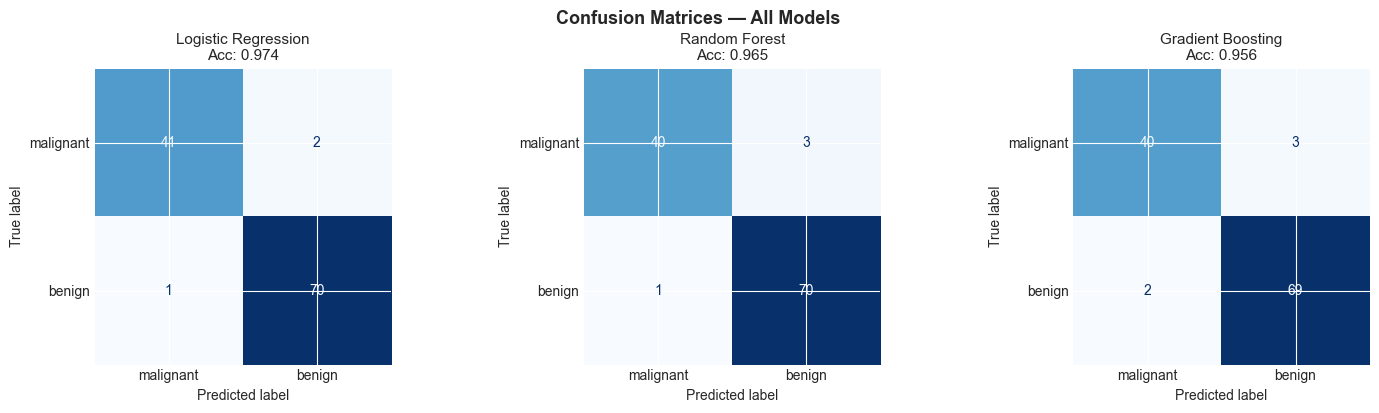

In [4]:
# Accuracy and Confusion Matrix

# Train three classifiers for comparison

models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)

}

 

results = {}

 

for name, model in models.items():

    model.fit(X_train_c, y_train_c)

    y_pred = model.predict(X_test_c)

    y_proba = model.predict_proba(X_test_c)[:, 1]

 

    results[name] = {

        'model': model,

        'y_pred': y_pred,

        'y_proba': y_proba,

        'accuracy': accuracy_score(y_test_c, y_pred),

        'cm': confusion_matrix(y_test_c, y_pred)

    }

    print(f"{name}: Accuracy = {results[name]['accuracy']:.4f}")

 

# ── Visualise confusion matrices side by side ──

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

 

for ax, (name, res) in zip(axes, results.items()):

    disp = ConfusionMatrixDisplay(

        confusion_matrix=res['cm'],

        display_labels=cancer.target_names

    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontsize=11)

 

plt.tight_layout()

plt.suptitle("Confusion Matrices — All Models", y=1.02, fontsize=13, fontweight='bold')

plt.show()

 
#Accuracy and confusion matrix for breast cancer
 

 

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Class imbalance ratio: 0.59


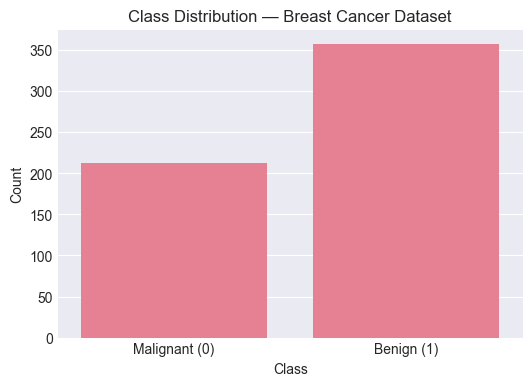

In [5]:
#Dataset preparation

 

# STUDENT TASKS

# 1. Print the feature names of breast cancer dataset

# 2. Caldulate and print class imbalance ratio (malignant/benign)

# 3. Plot a bar chart showing class distribution

 

#1 TODO: Print first 5 feature names

print("Feature names:", cancer.feature_names[:5])

 

#2 TODO: Calculate imbalance ratio

 

#malignant = 0, benign = 1

malignant = (y_clf == 0).sum()

benign = (y_clf == 1).sum()

 

imbalance_ratio = malignant / benign

print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

 

#3 TODO: Plot class distribution

plt.figure(figsize=(6, 4))

# your code here

 

sns.countplot(x=y_clf)

plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])

 

plt.title("Class Distribution — Breast Cancer Dataset")

 

plt.xlabel("Class")

plt.ylabel("Count")

 

plt.show()

In [6]:
# ── 🎓 STUDENT TASK 2 ·

# Confusion Matrix Deep Dive ────────────────────# Instructions:#  

# 1. Pick the Logistic Regression model's confusion matrix#  

# 2. Extract TP, FP, TN, FN values manually#  

# 3. Calculate accuracy from scratch (without sklearn) and verify it matches

# ## Recall: sklearn's confusion_matrix returns:#   [[TN, FP],#    [FN, TP]]

 

# Instructions:#   1. Pick the Logistic Regression model's confusion matrix

# #   2. Extract TP, FP, TN, FN values manually#  

# 3. Calculate accuracy from scratch (without sklearn) and verify it matches## Recall: sklearn's confusion_matrix returns:#   [[TN, FP],#    [FN, TP]]

 

 

# Train model

#Creates the model

model = LogisticRegression()

#Learns patterns from training data

model.fit(X_train_c, y_train_c)

 

# Predictions

#Model tries to predict: malignant (0) or benign (1)

y_pred = model.predict(X_test_c)

 

# Confusion matrix

cm = confusion_matrix(y_test_c, y_pred)

print("Confusion Matrix:\n", cm)

 

# Extract values

TN = cm[0][0]

FP = cm[0][1]

FN = cm[1][0]

TP = cm[1][1]

 

print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

 

# Manual accuracy

accuracy_manual = (TP + TN) / (TP + TN + FP + FN)

print(f"Manual Accuracy: {accuracy_manual:.4f}")

 

# Sklearn accuracy

accuracy_builtin = accuracy_score(y_test_c, y_pred)

print(f"Sklearn Accuracy: {accuracy_builtin:.4f}")

 

 



 



Confusion Matrix:
 [[41  2]
 [ 1 70]]
TN: 41, FP: 2, FN: 1, TP: 70
Manual Accuracy: 0.9737
Sklearn Accuracy: 0.9737
